In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import pipeline as pipeline
print(pipeline.__file__)

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py


In [12]:
input_dir  = './input_data'
stage_dirs = ['amd_sim_data_Early_European', 'amd_sim_data_Intermediate_European', 'amd_sim_data_Late-dry_European', 'amd_sim_data_Late-wet_European']
stage      = stage_dirs[3]
print(stage)

pm_model = pipeline.initiliaze_pipeline(f'{input_dir}/{stage}', verbose=True) 

amd_sim_data_Late-wet_European
number of rows: 135
number of unique location_id: 14
number of nodes: 233
number of edges: 232


In [13]:
rate_types = ['beta_binom', 'binom', 'neg_binom', 'poisson', 'log_normal', 'normal', 'offset_log_normal']
rate_type = rate_types[2]

pipeline.generate_pymc_objects(pm_model, rate_type=rate_type, include_covariates=True)

Standard errors replaced: 0
Effective sample sizes filled: 0
     31   56   58   64   70   71   100  102  73   78   79   80   81   82    
0    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  \
1    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0   
2    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0   
3    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0   
4    0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
130  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
131  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
132  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
133  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
134  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0   

     84   86  

In [14]:
map_estimate = pipeline.return_map_estimate(pm_model=pm_model, verbose=True)

INFO:pipeline:  ▶ pm.find_MAP() 수행 중...


In [15]:
idata = pipeline.return_idata(pm_model     = pm_model, 
                            map_estimate   = map_estimate, 
                            draws          = 2000,
                            tune           = 1000,
                            chains         = 4,
                            cores          = 4,
                            target_accept  = 0.9,
                            max_treedepth  = 10,
                            use_advi       = False,
                            use_metropolis = True,
                            verbose=True
                            ) 
# 198.3초 소요

INFO:pipeline:  ▶ Metropolis 샘플링 수행 중...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc:CompoundStep
>Metropolis: [gamma_p]
INFO:pymc:>Metropolis: [gamma_p]
>Metropolis: [sigma_alpha_p_0_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_0_z]
>Metropolis: [sigma_alpha_p_1_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_1_z]
>Metropolis: [sigma_alpha_p_2_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_2_z]
>Metropolis: [sigma_alpha_p_3_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_3_z]
>Metropolis: [sigma_alpha_p_4_z]
INFO:pymc:>Metropolis: [sigma_alpha_p_4_z]
>Metropolis: [alpha_p_31]
INFO:pymc:>Metropolis: [alpha_p_31]
>Metropolis: [alpha_p_56]
INFO:pymc:>Metropolis: [alpha_p_56]
>Metropolis: [alpha_p_58]
INFO:pymc:>Metropolis: [alpha_p_58]
>Metropolis: [alpha_p_64]
INFO:pymc:>Metropolis: [alpha_p_64]
>Metropolis: [alpha_p_70]
INFO:pymc:>Metropolis: [alpha_p_70]
>Metropolis: [alpha_p_71]
INFO:pymc:>Metropolis: [alpha_p_71]
>Metropolis: [alpha

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.
INFO:pymc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
INFO:pymc:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
INFO:pipeline:[asr] 전체 소요 시간: 65.8초


In [16]:
summary_df = pipeline.return_rhat(idata)

Total vars:    883
R-hat > 1.01:  357
R-hat <= 1.01:  466
R-hat missing: 60
<xarray.Dataset> Size: 13kB
Dimensions:               (knot: 6, age: 101, cum_sum_mu_p_dim_0: 101,
                           mu_interval_p_dim_0: 135, pi_p_dim_0: 135,
                           obs_dim: 135, p_pred_p_dim_0: 135)
Coordinates:
  * knot                  (knot) float64 48B 0.0 30.0 45.0 60.0 80.0 100.0
  * age                   (age) float64 808B 0.0 1.0 2.0 3.0 ... 98.0 99.0 100.0
  * cum_sum_mu_p_dim_0    (cum_sum_mu_p_dim_0) int64 808B 0 1 2 3 ... 98 99 100
  * mu_interval_p_dim_0   (mu_interval_p_dim_0) int64 1kB 0 1 2 ... 132 133 134
  * pi_p_dim_0            (pi_p_dim_0) int64 1kB 0 1 2 3 4 ... 131 132 133 134
  * obs_dim               (obs_dim) int64 1kB 0 1 2 3 4 ... 130 131 132 133 134
  * p_pred_p_dim_0        (p_pred_p_dim_0) int64 1kB 0 1 2 3 ... 131 132 133 134
Data variables: (12/42)
    gamma_p               (knot) float64 48B 1.015 1.014 1.017 1.031 1.053 1.04
    sigma_alpha_p_0_

In [ ]:
pred = pipeline.predict_for(pm_model            = pm_model,
                            idata               = idata, 
                            root_area           = 'Global',
                            root_sex            = 'Both',
                            root_year           = 'all',
                            area                = 'Global',
                            sex                 = 'Both',
                            year                = 2019,
                            population_weighted = True,
                            lower               = 0.0,
                            upper               = 1.0,
                            )

/Users/jeonsang-eon/dismod_mr_migrated/reforged_mr/pipeline.py:759: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hpd = pm.stats.hdi(pred, hdi_prob=0.95)


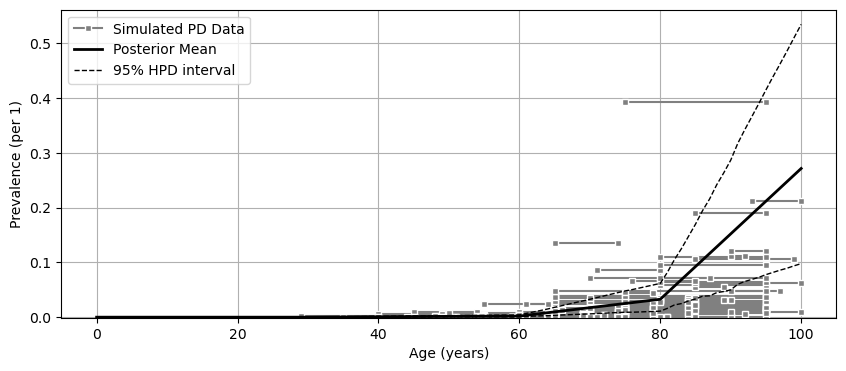

In [19]:
pipeline.visualize_pred(pred, pm_model.shared_data["data"])